In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('data/clean/social_media_impact_clean.csv')
df.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


**Step 4: Exploratory Data Analysis (EDA):Let's begin with the question your project brief specifically asks about: how usage patterns differ across students.Why start here: before jumping to relationships between variables (usage vs sleep, usage vs GPA), you first want to understand who your students actually are — their age spread, gender split, and how much they use social media on average. This gives you context for everything that comes after.**

In [2]:
df['Daily_Usage_Hours'].describe()

count    4500.000000
mean        5.295933
std         2.604497
min         0.900000
25%         3.400000
50%         4.700000
75%         6.600000
max        14.000000
Name: Daily_Usage_Hours, dtype: float64

In [4]:
df.groupby('Academic_Level')['Daily_Usage_Hours'].mean().sort_values(ascending=False)

Academic_Level
High School      5.326879
Undergraduate    5.293302
Postgraduate     5.139837
Name: Daily_Usage_Hours, dtype: float64

In [5]:
df.groupby('Gender')['Daily_Usage_Hours'].mean().sort_values(ascending=False)

Gender
Non-Binary           5.395902
Prefer not to say    5.362366
Female               5.324440
Male                 5.255924
Name: Daily_Usage_Hours, dtype: float64

In [6]:
df['Gender'].value_counts()

Gender
Female               2234
Male                 2051
Non-Binary            122
Prefer not to say      93
Name: count, dtype: int64

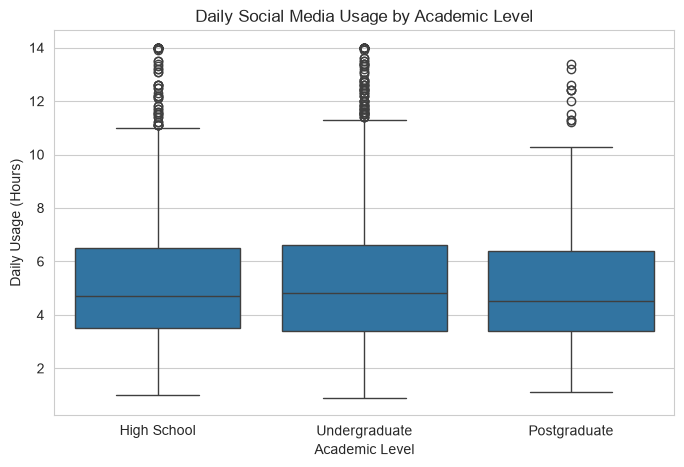

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Academic_Level', y='Daily_Usage_Hours', order=['High School', 'Undergraduate', 'Postgraduate'])
plt.title('Daily Social Media Usage by Academic Level')
plt.xlabel('Academic Level')
plt.ylabel('Daily Usage (Hours)')
plt.show()

**Interpretation:** Daily usage is very similar across High School, Undergraduate, 
and Postgraduate students, with medians all around 4.5–5 hours/day. High School 
and Undergraduate students show more high-usage outliers (11+ hours/day) than 
Postgraduate students, but academic level does not appear to be a strong driver 
of usage differences overall.

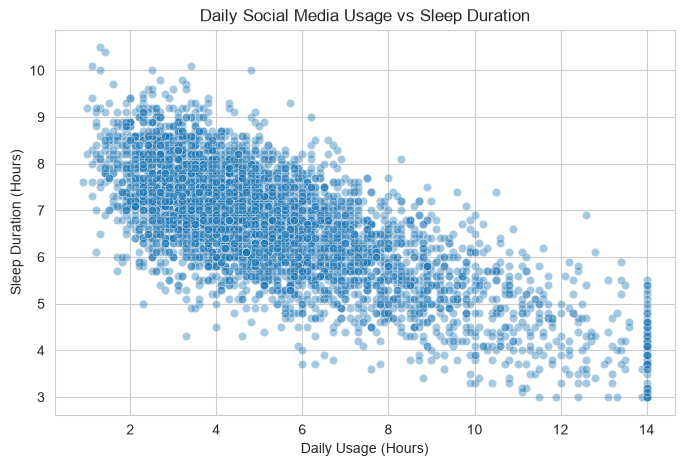

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Sleep_Duration_Hours', alpha=0.4)
plt.title('Daily Social Media Usage vs Sleep Duration')
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('Sleep Duration (Hours)')
plt.show()

In [8]:
df['Daily_Usage_Hours'].corr(df['Sleep_Duration_Hours'])

np.float64(-0.7159026019117339)

**Interpretation:** There is a clear negative relationship between daily social 
media usage and sleep duration (correlation = -0.72). Students who spend more 
hours on social media each day tend to sleep noticeably less — those using 
2 hours a day average close to 9-10 hours of sleep, while those using 10+ hours 
a day often sleep only 4-6 hours. This is a much stronger pattern than anything 
we saw across academic levels or gender, and it's a strong candidate for one of 
the key insights in the final report: heavier social media use is closely tied 
to reduced sleep.

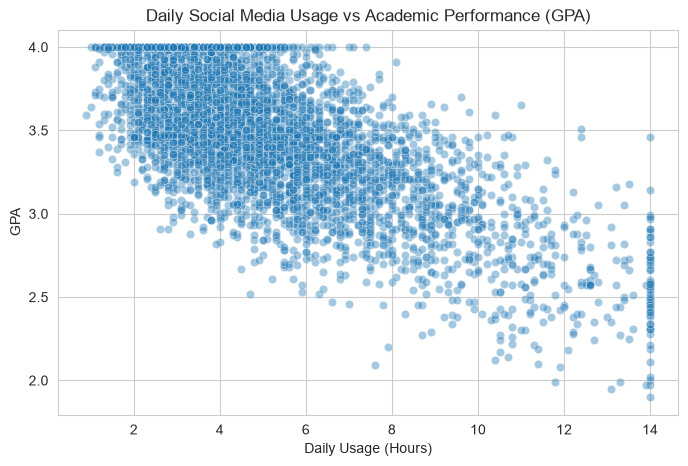

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Academic_Performance_GPA', alpha=0.4)
plt.title('Daily Social Media Usage vs Academic Performance (GPA)')
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('GPA')
plt.show()

In [12]:
df['Daily_Usage_Hours'].corr(df['Academic_Performance_GPA'])

np.float64(-0.7043549623376275)

**Interpretation:** There is a clear negative relationship between daily social 
media usage and academic performance (correlation = -0.70). Students who spend 
more hours on social media each day tend to have noticeably lower GPA — those 
using 2 hours a day average around 3.5-4.0, while those using 10+ hours a day 
often drop to around 2.5-3.0 or lower. This is nearly as strong as the sleep 
pattern (-0.72) and reinforces the same message: heavier social media use is 
closely tied to worse academic outcomes, not just poorer sleep.

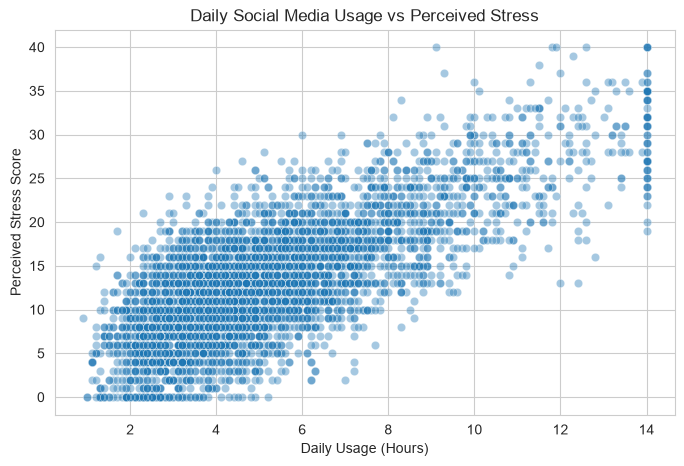

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Perceived_Stress_Score', alpha=0.4)
plt.title('Daily Social Media Usage vs Perceived Stress')
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('Perceived Stress Score')
plt.show()

In [11]:
df['Daily_Usage_Hours'].corr(df['Perceived_Stress_Score'])

np.float64(0.7506807355245134)

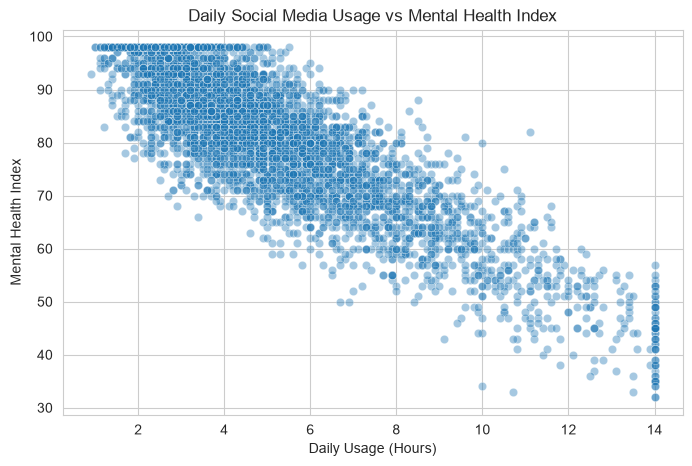

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Daily_Usage_Hours', y='Mental_Health_Index', alpha=0.4)
plt.title('Daily Social Media Usage vs Mental Health Index')
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('Mental Health Index')
plt.show()

In [13]:
df['Daily_Usage_Hours'].corr(df['Mental_Health_Index'])

np.float64(-0.8499077942620484)

**Interpretation:** There is a strong positive correlation between daily social 
media usage and perceived stress (correlation = +0.75). Students using around 
2 hours a day average a stress score near 5-10, while those using 10+ hours a 
day often average 25-30 or higher. There is an even stronger negative correlation 
with Mental Health Index (correlation = -0.85), the strongest relationship found 
so far — students at 2 hours/day average a mental health score near 90-100, while 
those at 12-14 hours/day often drop to 40-60. Together, these two charts tell a 
consistent story: heavier social media use is closely tied not just to less sleep 
and lower grades, but to higher stress and poorer overall mental wellbeing.

**Overall_Impact Breakdown**

In [14]:
df['Overall_Impact'].value_counts()

Overall_Impact
Beneficial    3681
Neutral        654
Negative       165
Name: count, dtype: int64

**average usage for each group.**

In [15]:
df.groupby('Overall_Impact')['Daily_Usage_Hours'].mean().sort_values(ascending=False)

Overall_Impact
Negative      12.250303
Neutral        8.498012
Beneficial     4.415295
Name: Daily_Usage_Hours, dtype: float64

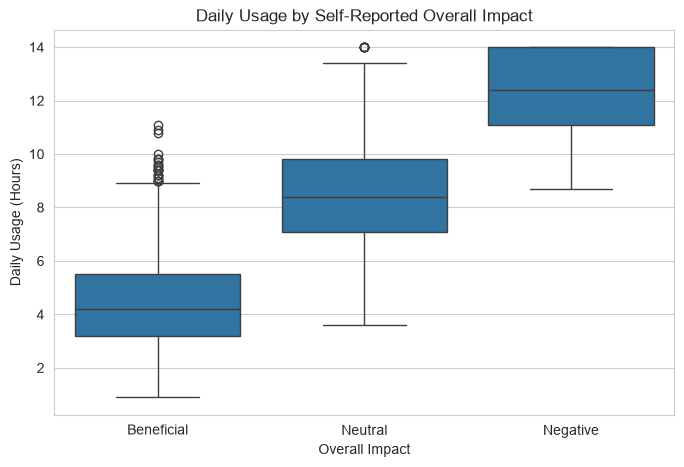

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Overall_Impact', y='Daily_Usage_Hours', order=['Beneficial', 'Neutral', 'Negative'])
plt.title('Daily Usage by Self-Reported Overall Impact')
plt.xlabel('Overall Impact')
plt.ylabel('Daily Usage (Hours)')
plt.show()

**Interpretation:** Out of 4,500 students, the vast majority (3,681, or 82%) 
report social media as Beneficial, using an average of 4.4 hours/day. A smaller 
group (654) report a Neutral experience, averaging 8.5 hours/day, while only 165 
students (3.7%) report a Negative experience, averaging 12.3 hours/day — nearly 
3x the usage of the Beneficial group. This is one of the clearest patterns in 
the dataset: students who feel social media negatively affects them are, on 
average, using it far more heavily than those who feel it helps them. Combined 
with the earlier findings on sleep, GPA, stress, and mental health, this suggests 
that moderate usage is generally experienced as positive, while heavy usage 
(consistently 10+ hours/day) is where the negative effects tend to concentrate.

In [17]:
df.groupby('Late_Night_Usage')['Sleep_Duration_Hours'].mean()

Late_Night_Usage
False    7.085884
True     6.431392
Name: Sleep_Duration_Hours, dtype: float64

In [18]:
df.groupby('Late_Night_Usage')['Daily_Usage_Hours'].mean()

Late_Night_Usage
False    4.257920
True     6.024584
Name: Daily_Usage_Hours, dtype: float64

In [3]:
df['Primary_Platform'].value_counts()

Primary_Platform
Instagram      1453
TikTok         1226
YouTube         818
Snapchat        472
Reddit          229
X (Twitter)     206
LinkedIn         96
Name: count, dtype: int64

In [4]:
df.groupby('Primary_Platform')['Daily_Usage_Hours'].mean().sort_values(ascending=False)

Primary_Platform
Snapchat       5.457415
TikTok         5.330995
Reddit         5.313974
LinkedIn       5.267708
Instagram      5.261390
YouTube        5.248289
X (Twitter)    5.143204
Name: Daily_Usage_Hours, dtype: float64

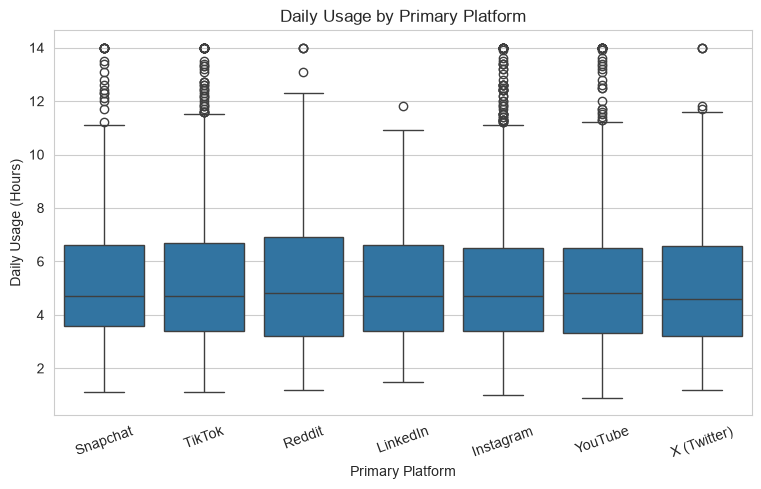

In [5]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Primary_Platform', y='Daily_Usage_Hours', order=df.groupby('Primary_Platform')['Daily_Usage_Hours'].mean().sort_values(ascending=False).index)
plt.title('Daily Usage by Primary Platform')
plt.xlabel('Primary Platform')
plt.ylabel('Daily Usage (Hours)')
plt.xticks(rotation=20)
plt.show()

**Interpretation:** The box plot shows all seven platforms sitting at nearly the 
same height, with medians roughly between 4.5 and 6 hours and heavily overlapping 
boxes — no platform is clearly shifted higher or lower than the others. Average 
daily usage backs this up numerically, ranging only from 5.14 hours (X/Twitter) 
to 5.46 hours (Snapchat), a spread of under 20 minutes. This is the same pattern 
seen with Academic Level and Gender: no single platform stands out as driving 
meaningfully higher or lower usage. This suggests the specific platform a student 
uses matters far less than the total amount of time spent overall — reinforcing 
that the sleep, GPA, stress, and mental health patterns found earlier are tied to 
usage volume, not to any one app.

### 1. Heavy usage (10+ hours/day) is where negative outcomes concentrate
Students who report social media as harming them use it nearly 3x more than 
those who report it as beneficial (12.3 hrs/day vs 4.4 hrs/day).
**Evidence:** Overall_Impact groups show a clean separation in usage hours, 
with almost no overlap between Beneficial and Negative groups.
**Recommendation:** Rather than discouraging social media use entirely, 
conversations with students should focus on keeping daily usage below the 
8-hour range where Neutral/Negative experiences become more common.

### 2. Higher usage is strongly linked to reduced sleep
Students who spend more hours on social media each day tend to sleep noticeably 
less — those using around 2 hours a day average 9-10 hours of sleep, while those 
using 10+ hours a day often sleep only 4-6 hours.
**Evidence:** Daily usage and sleep duration show a strong negative correlation 
(-0.72). Late-night usage alone only accounts for a modest sleep difference 
(6.4 hrs vs 7.1 hrs), but late-night users also average nearly 2 more hours of 
total daily usage (6.0 hrs vs 4.3 hrs) — suggesting total usage volume, not just 
late-night timing, is the main driver of the sleep effect.
**Recommendation:** Rather than focusing only on a late-night curfew, the priority 
should be reducing total daily usage — particularly for students already averaging 
8+ hours a day, where the sleep impact becomes most severe.

In [19]:
df['Late_Night_Usage'].value_counts()

Late_Night_Usage
True     2644
False    1856
Name: count, dtype: int64

### 3. Higher usage is strongly linked to lower academic performance
Students who spend more hours on social media each day tend to have noticeably 
lower GPA. Those using around 2 hours a day average GPA around 3.5-4.0, while 
those using 10+ hours a day often drop to around 2.5-3.0 or lower.
**Evidence:** Daily usage and GPA show a strong negative correlation (-0.70), 
one of the clearest relationships in the dataset.
**Recommendation:** Parents and teachers could establish protected, phone-free 
study periods each day, rather than relying only on a general time limit — since 
the data suggests it's competing for study time (not usage itself) that's most 
closely tied to lower GPA.

### 4. Higher usage is linked to more stress and poorer mental health
Students who spend more hours on social media each day report higher stress and 
lower mental wellbeing. Those using around 2 hours a day average a stress score 
near 5-10 and a mental health score near 90-100, while those using 10+ hours a 
day often average a stress score of 25-30+ and a mental health score of 40-60.
**Evidence:** Daily usage shows a strong positive correlation with Perceived 
Stress Score (+0.75) and an even stronger negative correlation with Mental 
Health Index (-0.85) — the strongest relationship found in the entire dataset.
**Recommendation:** Since heavy usage often involves frequent social comparison 
(scrolling, comparing oneself to others), parents and teachers could focus 
conversations on *how* students use social media, not just how long — 
encouraging awareness of social comparison habits specifically, alongside 
reducing total hours.

### 5. The platform doesn't matter — total usage hours do
Average daily usage is nearly identical across all seven platforms (Snapchat, 
TikTok, Reddit, LinkedIn, Instagram, YouTube, X/Twitter), ranging only from 
5.14 to 5.46 hours — a spread of under 20 minutes, with heavily overlapping 
box plots.
**Evidence:** Unlike the strong relationships found for usage vs sleep, GPA, 
stress, and mental health, platform choice shows no meaningful pattern — the 
same near-identical spread seen earlier across Academic Level and Gender.
**Recommendation:** Conversations with students and parents shouldn't focus on 
which app is "worse" — the data doesn't support that. Instead, keep the focus 
on total daily hours across all apps combined, since that is what's actually 
driving the outcomes in this analysis.